# Watershed DT Testing
This notebook handles sanity testing of the watershed DT through figure production. None of these figures are in the main or supplemental materials but still useful for understanding the process.

In [1]:
import xarray as xa
import numpy as np
import regionmask
from pynhd import pynhd
import cftime
import pandas as pd
import geopandas as gpd
from glob import glob
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib as mpl

ERROR 1: PROJ: proj_create_from_database: Open of /glade/u/home/tcorrie/.conda/envs/rmask/share/proj failed


In [2]:
huc4s = gpd.read_file('/glade/u/home/tcorrie/watersheds_WUS.geojson', driver='GeoJSON')
ar_mask = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARmasks/G18/ARmask.era5.nan.nc')
ar_mask = ar_mask.where(ar_mask.ARmask == 1)

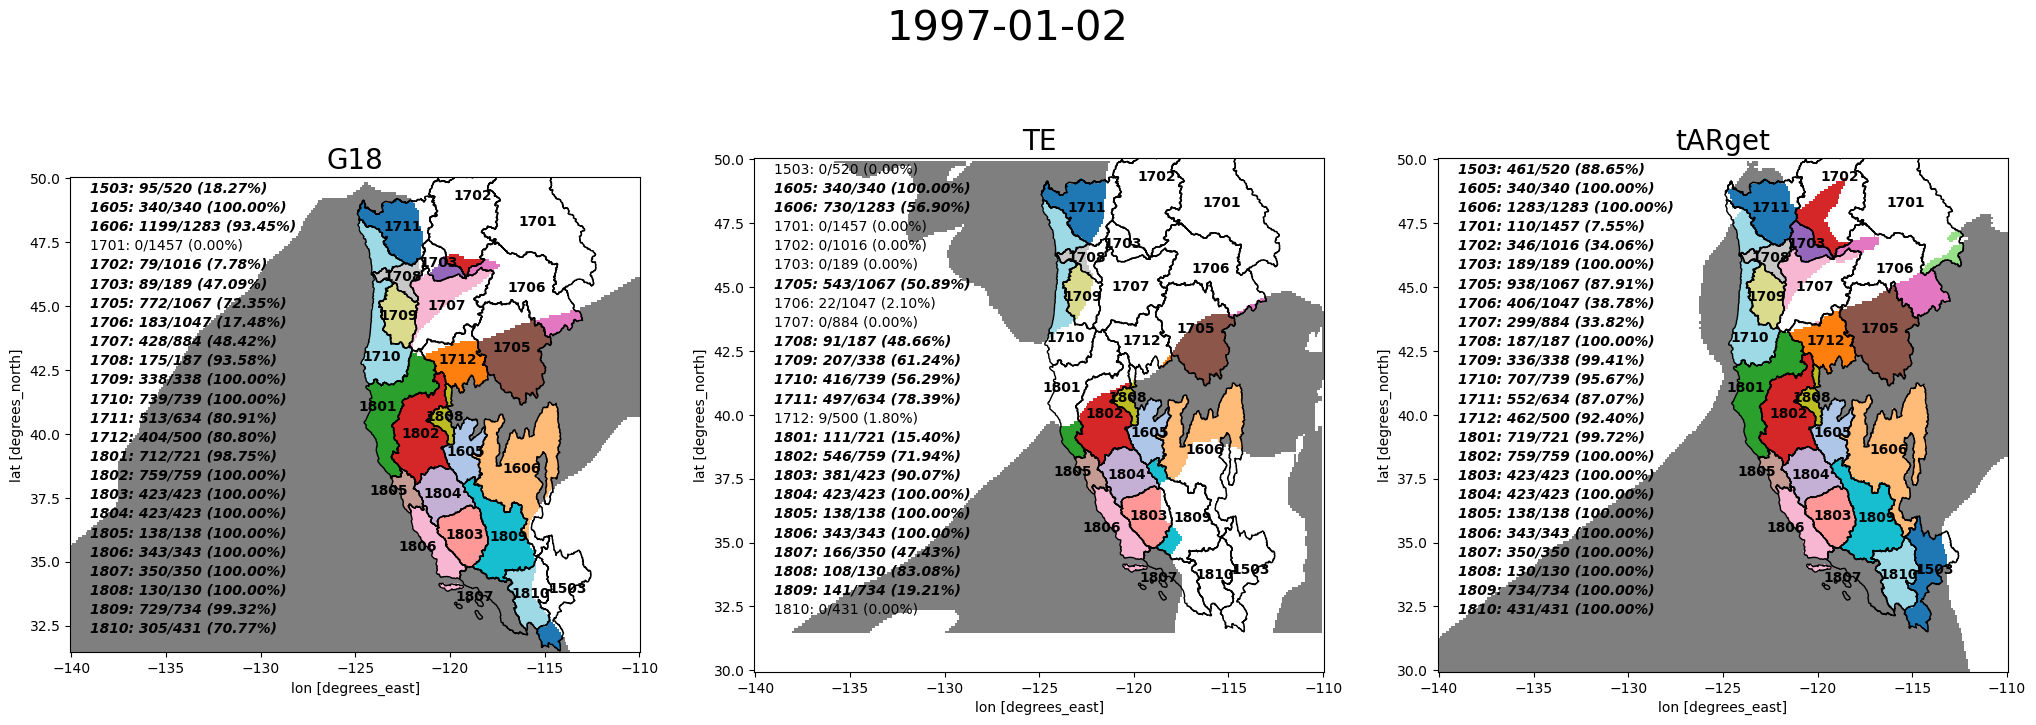

In [8]:
# Input parameters
model = 'era5'
member = 'nan'
tstep = 365*46+135

# Plot creation
fig, ax = plt.subplots(1,3,figsize=(25,10))
custom_cmap = ListedColormap(mpl.colormaps['tab20'].colors*2)

# Loop through the three ARDTs
for i, ardt in enumerate(['G18', 'TE', 'tARget']):
    arwshed = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARwatershed/{ardt}/ARwshed.{ardt}.{model}.{member}.nc')
    arwshed_mask = xa.open_dataset(f'/glade/derecho/scratch/tcorrie/ARdata/ARwatershedmask/{ardt}/ARwshedmsk.{ardt}.{model}.{member}.nc')
    ar_mask = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARmasks/{ardt}/ARmask.{model}.{member}.nc')

    # Remove NaN values from the ARmask
    if ardt == 'tARget':
        ar_mask = ar_mask.fillna(0)
    
    onetime = arwshed.isel(time=tstep)
    wshed_all = onetime.watershed.values
    wshed_values = onetime.where(onetime.ARwshed == 1).dropna(dim='watershed').watershed.values

    # Apply a regionmask to the AR Mask. Split by watershed, 0-indexed. Nan where there's no ARmask over a watershed.
    rmasks = regionmask.mask_geopandas(huc4s, ar_mask.lon, ar_mask.lat)

    # Cell count
    total_count = [rmasks.where(rmasks == idx).count().values for idx in range(len(huc4s))]
    masked_count = [(arwshed_mask.isel(time=tstep).wshed_mask*rmasks.where(rmasks == idx)).count().values for idx in range(len(huc4s))]
    
    texts = [f"{w}: {m}/{t} ({m/t:.2%})" for w, m, t in zip(wshed_all, masked_count, total_count)]
    
    huc4s.plot(ax=ax[i], facecolor="none", edgecolor='k', zorder=5) # Plot the watershed boundaries
    arwshed_mask.isel(time=tstep).wshed_mask.plot(ax=ax[i], add_colorbar=False, cmap=custom_cmap, levels=np.arange(0,25)) # Plot the AR Mask with the regionmask filter applied
    ar_mask.isel(time=tstep).ARmask.plot(cmap='binary', alpha=0.5, zorder=-1, add_colorbar=False, ax=ax[i]) # Plot the original AR mask, where the AR mask doesn't overlap a watershed
    # The next chunk fine-tunes the position of the HUC4 ID text as not every centroid behaves correctly.
    for ct, text in enumerate(texts):
        ax[i].text(-139, 49.9-0.75*ct, text, va='top', fontweight='bold', fontstyle='italic') if wshed_all[ct] in wshed_values else ax[i].text(-139, 49.9-0.75*ct, text, va='top')
    for row in range(len(huc4s)):
        huc4_id = huc4s.loc[row, 'huc4']
        cent_x = huc4s.loc[row, 'geometry'].centroid.x
        cent_y = huc4s.loc[row, 'geometry'].centroid.y
        if huc4_id=='1710':
            ax[i].annotate(text=huc4_id, xy=[cent_x, cent_y-1.5], color='k', fontsize=10, ha='center', va='center', weight='bold')
        elif huc4_id in ['1801', '1805', '1806', '1807']:
            ax[i].annotate(text=huc4_id, xy=[cent_x-1, cent_y], color='k', fontsize=10, ha='center', va='center', weight='bold')
        elif huc4_id in ['1809', '1503']:
            ax[i].annotate(text=huc4_id, xy=[cent_x+0.4, cent_y], color='k', fontsize=10, ha='center', va='center', weight='bold')
        else:
            ax[i].annotate(text=huc4_id, xy=[cent_x, cent_y], color='k', fontsize=10, ha='center', va='center', weight='bold')
    ax[i].set_title(ardt, fontsize=20)
    fig.suptitle(onetime.time.dt.strftime('%Y-%m-%d').values, fontsize=30, y=0.9)

In [4]:
#fig.savefig('/glade/u/home/tcorrie/TestFigs/watershed_test_19970102.png', bbox_inches='tight', dpi=600)

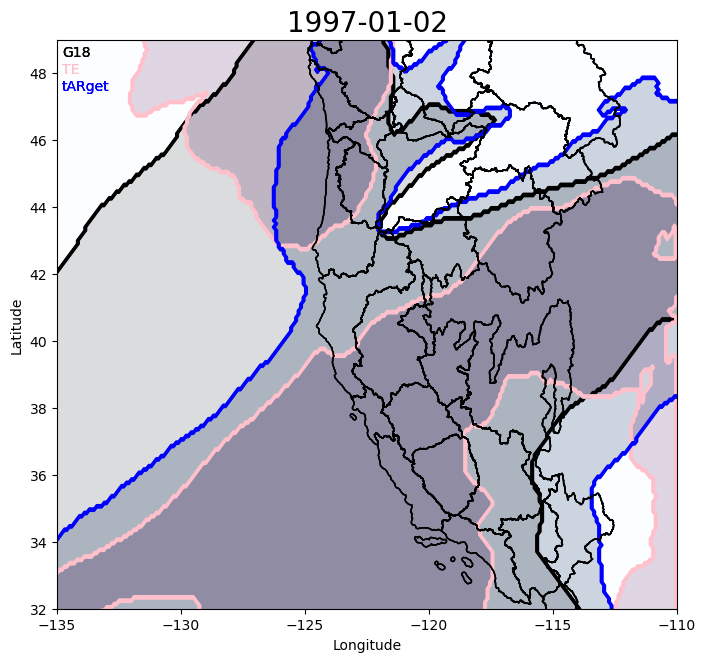

In [21]:
# This plot take the above masks and overlays them onto one map.

f2, a2 = plt.subplots(1,1,figsize=(8,8))
for i, ardt in enumerate(['G18', 'TE', 'tARget']):
    arwshed = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARwatershed/{ardt}/ARwshed.{ardt}.{model}.{member}.nc')
    arwshed_mask = xa.open_dataset(f'/glade/derecho/scratch/tcorrie/ARdata/ARwatershedmask/{ardt}/ARwshedmsk.{ardt}.{model}.{member}.nc')
    ar_mask = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARmasks/{ardt}/ARmask.{model}.{member}.nc')

    if ardt == 'tARget':
        ar_mask = ar_mask.fillna(0)
    
    onetime = arwshed.isel(time=tstep)
    wshed_all = onetime.watershed.values
    wshed_values = onetime.where(onetime.ARwshed == 1).dropna(dim='watershed').watershed.values
    
    rmasks = regionmask.mask_geopandas(huc4s, ar_mask.lon, ar_mask.lat)
    
    total_count = [rmasks.where(rmasks == idx).count().values for idx in range(len(huc4s))]
    masked_count = [(arwshed_mask.isel(time=tstep).wshed_mask*rmasks.where(rmasks == idx)).count().values for idx in range(len(huc4s))]
    
    texts = [f"{w}: {m}/{t} ({m/t:.2%})" for w, m, t in zip(wshed_all, masked_count, total_count)]
    
    huc4s.plot(ax=a2, facecolor="none", edgecolor='k', zorder=5)
    arwshed_mask.isel(time=tstep).wshed_mask.plot(ax=ax[i], add_colorbar=False, cmap=custom_cmap, levels=np.arange(0,25))
    
    colorss = {'G18':'black', 'TE':'pink', 'tARget':'blue'}
    cmaps = {'G18':'binary', 'TE':'BuPu', 'tARget':'Blues'}
    ar_mask.isel(time=tstep).ARmask.plot.contour(colors=colorss[ardt], ax=a2)
    ar_mask.isel(time=tstep).ARmask.plot(cmap=cmaps[ardt], ax=a2, alpha=0.2, add_colorbar=False)

    a2.text(-134.8, 48.5, 'G18', color='k')
    a2.text(-134.8, 48.0, 'TE', color='pink')
    a2.text(-134.8, 47.5, 'tARget', color='blue')
    a2.set_ylim(32,49)
    a2.set_xlim(-135,-110)
    a2.set_ylabel("Latitude")
    a2.set_xlabel("Longitude")
    a2.set_title(onetime.time.dt.strftime('%Y-%m-%d').values, fontsize=20)